# Chapter 3 - Statistical Experiments and Significance Testing

Reproduksi pembelajaran buku **Practical Statistics for Data Scientists: 50+ Essential Concepts Using R and Python**, edisi kedua, Peter Bruce, Andrew Bruce, dan Peter Gedeck (O'Reilly, 2020).

Kode dasar diadaptasi dari [notebook penulis](https://github.com/gedeck/practical-statistics-for-data-scientists/blob/8a6d3bb6468e979c861d4b37215e1413702dfdfa/python/notebooks/Chapter%203%20-%20Statistical%20Experiments%20and%20Significance%20Testing.ipynb). Copyright (c) 2019 Peter C. Bruce, Andrew Bruce, Peter Gedeck; lisensi GPL-3.0 disertakan pada repo.

**Tujuan:** Mempelajari desain eksperimen, pengujian hipotesis, dan kebutuhan sampel melalui contoh waktu halaman web, conversion, dan klik headline. Pembahasan menghubungkan konsep dengan kode dan hasil eksekusi. Dataset tersedia di `data/`, dan output tersimpan agar notebook dapat dibaca langsung. Petunjuk menjalankan ulang serta identitas mahasiswa tercantum pada README.

**Adaptasi:** ANOVA F dan p-value tidak dibagi dua; arah uji t eksplisit; selisih conversion diselaraskan dengan arah permutation; p-value simulasi memakai koreksi +1; sampling dengan pengembalian memakai random.choices; power dua proporsi memakai NormalIndPower; Fisher 2x2 benar-benar dijalankan.

## Daftar isi

- [Desain eksperimen dan risiko interpretasi](#desain-eksperimen-dan-risiko-interpretasi)
- [Resampling](#resampling)
- [Statistical Significance and P-Values](#statistical-significance-and-p-values)
- [t-Tests](#t-tests)
- [ANOVA](#anova)
- [Chi-Square Test](#chi-square-test)
- [Power and Sample Size](#power-and-sample-size)
- [Pemeriksaan hasil dan interpretasi](#pemeriksaan-hasil-dan-interpretasi)
- [A/B Testing dan Hypothesis Tests](#ab-testing-dan-hypothesis-tests)
- [Exhaustive dan Bootstrap Permutation Tests](#exhaustive-dan-bootstrap-permutation-tests)
- [Degrees of Freedom dan Relevansi untuk Pembelajaran Mesin](#degrees-of-freedom-dan-relevansi-untuk-pembelajaran-mesin)
- [Multi-Arm Bandit Algorithm](#multi-arm-bandit-algorithm)
- [Ringkasan bab](#ringkasan-bab)

## Desain eksperimen dan risiko interpretasi

Tentukan unit eksperimen, kontrol, treatment, metrik utama, hipotesis, arah uji, dan jumlah sampel sebelum analisis. Blindness dapat mengurangi bias pengukuran; blocking membandingkan treatment dalam kelompok serupa. A/B testing memerlukan assignment yang konsisten dan tidak mengabaikan dependensi, misalnya kunjungan berulang pengguna sama.

**Multiple testing:** semakin banyak hipotesis diuji, semakin tinggi peluang false positive. Bonferroni memakai alpha/m untuk m uji guna mengendalikan family-wise error; Benjamini-Hochberg mengendalikan false discovery rate dengan tujuan berbeda. Memilih hasil signifikan dari banyak percobaan atau berhenti tepat saat p < 0,05 dapat menghasilkan kesimpulan menyesatkan. Laporkan effect size, ketidakpastian, dan desain pengujian bersama p-value.

Derajat bebas menyatakan jumlah informasi independen setelah pembatasan/estimasi parameter. Pada uji independensi tabel r x c, df = (r-1)(c-1); pada ANOVA, df antar-kelompok k-1 dan df dalam-kelompok N-k.

In [1]:
%matplotlib inline

from pathlib import Path
import random

import pandas as pd
import numpy as np

from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats import power

import matplotlib.pylab as plt

In [2]:
# Jalankan dari root repo atau folder notebooks.
ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
DATA = ROOT / 'data'
assert DATA.is_dir(), 'Jalankan notebook dari root repo atau folder notebooks.'
np.random.seed(42)
random.seed(42)


In [3]:
WEB_PAGE_DATA_CSV = DATA / 'web_page_data.csv'
FOUR_SESSIONS_CSV = DATA / 'four_sessions.csv'
CLICK_RATE_CSV = DATA / 'click_rates.csv'
IMANISHI_CSV = DATA / 'imanishi_data.csv'

## Resampling

Eksperimen A/B membandingkan perlakuan A dan B dengan metrik yang ditetapkan sebelumnya. Random assignment mengurangi confounding antar-kelompok. Hipotesis nol pada contoh menyatakan tidak ada perbedaan; statistiknya mean waktu B dikurangi A.

Permutation test mengacak label kelompok sambil mempertahankan ukuran kelompok. Ini membuat distribusi statistik di bawah hipotesis exchangeability. P-value satu arah menghitung seberapa sering statistik acak setidaknya sebesar selisih yang diamati. Uji ini tidak mengubah eksperimen observasional menjadi bukti kausal. Waktu pada dataset dikalikan 100 untuk mengikuti satuan detik pada contoh buku.

In [4]:
session_times = pd.read_csv(WEB_PAGE_DATA_CSV)
session_times.Time = 100 * session_times.Time

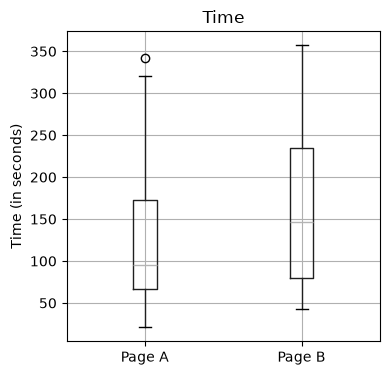

In [5]:
ax = session_times.boxplot(by='Page', column='Time',
                           figsize=(4, 4))
ax.set_xlabel('')
ax.set_ylabel('Time (in seconds)')
plt.suptitle('')

plt.tight_layout()
plt.show()

In [6]:
mean_a = session_times[session_times.Page == 'Page A'].Time.mean()
mean_b = session_times[session_times.Page == 'Page B'].Time.mean()
print(mean_b - mean_a)

35.66666666666667


In [7]:
# Permutation test example with stickiness
def perm_fun(x, nA, nB):
    n = nA + nB
    idx_B = set(random.sample(range(n), nB))
    idx_A = set(range(n)) - idx_B
    return x.loc[list(idx_B)].mean() - x.loc[list(idx_A)].mean()
    
nA = session_times[session_times.Page == 'Page A'].shape[0]
nB = session_times[session_times.Page == 'Page B'].shape[0]
print(perm_fun(session_times.Time, nA, nB))

35.09523809523809


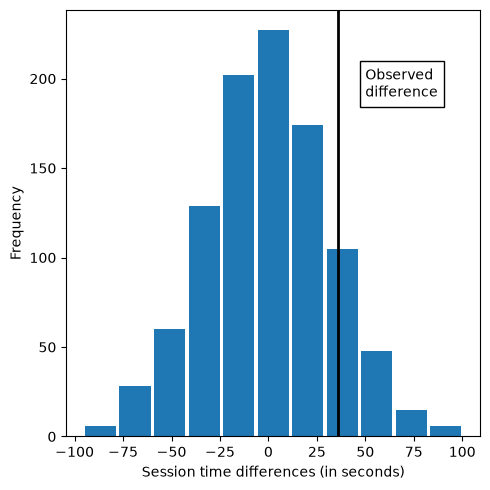

In [8]:
random.seed(1)
perm_diffs = [perm_fun(session_times.Time, nA, nB) for _ in range(1000)]

fig, ax = plt.subplots(figsize=(5, 5))
ax.hist(perm_diffs, bins=11, rwidth=0.9)
ax.axvline(x = mean_b - mean_a, color='black', lw=2)
ax.text(50, 190, 'Observed\ndifference', bbox={'facecolor':'white'})
ax.set_xlabel('Session time differences (in seconds)')
ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [9]:
perm_diffs = np.array(perm_diffs)
print((np.count_nonzero(perm_diffs >= mean_b - mean_a) + 1) / (len(perm_diffs) + 1))

0.12487512487512488


## Statistical Significance and P-Values

P-value adalah peluang memperoleh statistik setidaknya se-ekstrem hasil observasi **dengan asumsi hipotesis nol dan model uji benar**. Ini bukan peluang hipotesis nol benar dan bukan ukuran besarnya manfaat bisnis. Signifikansi statistik berbeda dari signifikansi praktis. Selisih conversion rate pada kode dinyatakan dalam poin persentase; arah statistik permutation diselaraskan dengan selisih observasi.

Observed difference: 0.0368%


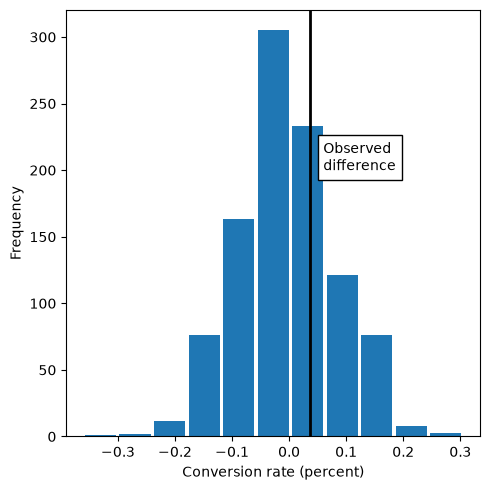

In [10]:
random.seed(1)
obs_pct_diff = 100 * (200 / 23739 - 182 / 22588)
print(f'Observed difference: {obs_pct_diff:.4f}%')
conversion = [0] * 45945
conversion.extend([1] * 382)
conversion = pd.Series(conversion)

perm_diffs = [100 * perm_fun(conversion, 22588, 23739) 
              for _ in range(1000)]

fig, ax = plt.subplots(figsize=(5, 5))
ax.hist(perm_diffs, bins=11, rwidth=0.9)
ax.axvline(x=obs_pct_diff, color='black', lw=2)
ax.text(0.06, 200, 'Observed\ndifference', bbox={'facecolor':'white'})
ax.set_xlabel('Conversion rate (percent)')
ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

### P-Value

Tentukan arah uji dan ambang $\alpha$ sebelum melihat hasil. Untuk $H_1$ satu arah, gunakan ekor yang sesuai; untuk dua arah, pertimbangkan kedua arah. Estimasi Monte Carlo diadaptasi menjadi $(b+1)/(B+1)$ agar tidak menghasilkan nol palsu dari jumlah pengulangan terbatas. Uji chi-square tabel conversion menghasilkan p-value dua arah untuk asosiasi; hasil itu tidak dibagi dua secara otomatis.

In [11]:
print((sum(diff >= obs_pct_diff for diff in perm_diffs) + 1) / (len(perm_diffs) + 1))

0.3386613386613387


In [12]:
survivors = np.array([[200, 23739 - 200], [182, 22588 - 182]])
chi2, p_value, df, _ = stats.chi2_contingency(survivors)

print(f'p-value chi-square (asosiasi, bukan satu arah): {p_value:.4f}')

p-value chi-square (asosiasi, bukan satu arah): 0.6996


## t-Tests

Welch t-test membandingkan mean dua kelompok tanpa mengasumsikan varians sama. Statistiknya $(\bar{x}_A-\bar{x}_B)/\sqrt{s_A^2/n_A+s_B^2/n_B}$. Contoh memakai alternatif A lebih kecil daripada B, sesuai statistik B-A positif.

Pengamatan harus independen; pada sampel kecil, distribusi dan outlier perlu diperhatikan. Kode SciPy memakai `alternative='less'` secara eksplisit, bukan membagi p-value dua arah tanpa memeriksa tanda. Tidak menolak $H_0$ tidak berarti membuktikan kedua mean identik.

In [13]:
res = stats.ttest_ind(session_times[session_times.Page == 'Page A'].Time, 
                      session_times[session_times.Page == 'Page B'].Time,
                      equal_var=False, alternative='less')
print(f'p-value for single sided test: {res.pvalue:.4f}')

p-value for single sided test: 0.1408


In [14]:
tstat, pvalue, df = sm.stats.ttest_ind(
    session_times[session_times.Page == 'Page A'].Time, 
    session_times[session_times.Page == 'Page B'].Time,
    usevar='unequal', alternative='smaller')
print(f'p-value: {pvalue:.4f}')

p-value: 0.1408


## ANOVA

ANOVA menguji apakah seluruh mean beberapa kelompok sama. Hipotesis alternatifnya setidaknya satu berbeda, bukan semua pasangan berbeda. Permutation dalam contoh mengacak waktu untuk menilai varians mean antarkelompok. Random seed NumPy diatur karena pengacakan dilakukan oleh NumPy, bukan hanya oleh modul `random`.

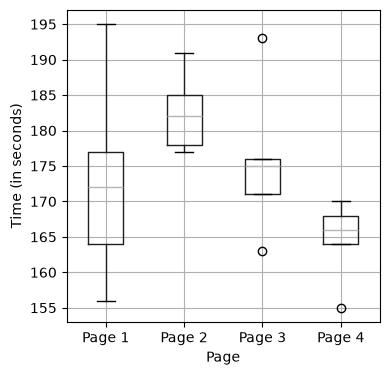

In [15]:
four_sessions = pd.read_csv(FOUR_SESSIONS_CSV)

ax = four_sessions.boxplot(by='Page', column='Time',
                           figsize=(4, 4))
ax.set_xlabel('Page')
ax.set_ylabel('Time (in seconds)')
plt.suptitle('')
plt.title('')

plt.tight_layout()
plt.show()

In [16]:
print(pd.read_csv(FOUR_SESSIONS_CSV).head())

     Page  Time
0  Page 1   164
1  Page 2   178
2  Page 3   175
3  Page 4   155
4  Page 1   172


In [17]:
observed_variance = four_sessions.groupby('Page').mean().var().iloc[0]
print('Observed means:', four_sessions.groupby('Page').mean().values.ravel())
print('Variance:', observed_variance)
# Permutation test example with stickiness
def perm_test(df):
    df = df.copy()
    df['Time'] = np.random.permutation(df['Time'].values)
    return df.groupby('Page').mean().var().iloc[0]
    
print(perm_test(four_sessions))

Observed means: [172.8 182.6 175.6 164.6]
Variance: 55.426666666666655
19.63999999999999


Pr(Prob) 0.0846384538487171


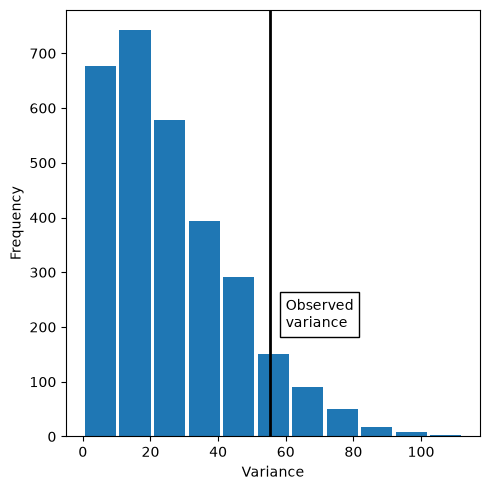

In [18]:
np.random.seed(1)
perm_variance = [perm_test(four_sessions) for _ in range(3000)]
print('Pr(Prob)', (sum(var >= observed_variance for var in perm_variance) + 1) / (len(perm_variance) + 1))

fig, ax = plt.subplots(figsize=(5, 5))
ax.hist(perm_variance, bins=11, rwidth=0.9)
ax.axvline(x = observed_variance, color='black', lw=2)
ax.text(60, 200, 'Observed\nvariance', bbox={'facecolor':'white'})
ax.set_xlabel('Variance')
ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

### F-Statistic

Statistik $F=MS_{between}/MS_{within}$ membandingkan variasi antarkelompok terhadap variasi di dalam kelompok. F besar memberi bukti terhadap kesamaan mean. P-value memakai ekor kanan distribusi F dan **tidak dibagi dua**. Kode sumber membagi F dan p-value dengan dua; reproduksi ini memperbaikinya. ANOVA klasik mengasumsikan independensi, error mendekati normal, dan varians kelompok homogen.

In [19]:
model = smf.ols('Time ~ Page', data=four_sessions).fit()
                
aov_table = sm.stats.anova_lm(model)
print(aov_table)

            df  sum_sq     mean_sq         F    PR(>F)
Page       3.0   831.4  277.133333  2.739825  0.077586
Residual  16.0  1618.4  101.150000       NaN       NaN


In [20]:
res = stats.f_oneway(four_sessions[four_sessions.Page == 'Page 1'].Time, 
                     four_sessions[four_sessions.Page == 'Page 2'].Time,
                     four_sessions[four_sessions.Page == 'Page 3'].Time,
                     four_sessions[four_sessions.Page == 'Page 4'].Time)
print(f'F-Statistic: {res.statistic:.4f}')
print(f'p-value: {res.pvalue:.4f}')

F-Statistic: 2.7398
p-value: 0.0776


#### Two-Way ANOVA

ANOVA dua arah melibatkan dua faktor dan dapat memasukkan interaksi. `C(faktor)` menyatakan kategorikal dan `A:B` interaksi. Formula sumber `len ~ C(supp) + C(dose) + C(supp):C(dose)` hanya ilustrasi karena dataset itu tidak disertakan pada notebook; tidak dijalankan sebagai eksperimen dengan data yang belum ada. Efek satu faktor bisa berbeda menurut tingkat faktor lain.

## Chi-Square Test

Uji chi-square independensi mengevaluasi hubungan dua variabel kategorikal. Frekuensi harapan $E_{ij}=R_iC_j/N$ dan statistik $\chi^2=\sum(O_{ij}-E_{ij})^2/E_{ij}$. Derajat bebas $(r-1)(c-1)$. Aproksimasi asimtotik memerlukan frekuensi harapan memadai dan pengamatan independen.

### Chi-Square Test: A Resampling Approach

Contoh tiga headline mempunyai 1.000 impresi per headline dan total 34 klik. Permutation membagikan ulang klik sambil mempertahankan total klik dan ukuran kelompok. Distribusi simulasi dibandingkan dengan statistik observasi; p-value Monte Carlo bisa berbeda sedikit dari chi-square asimtotik karena aproksimasi dan pengacakan.

In [21]:
# Table 3-4
click_rate = pd.read_csv(CLICK_RATE_CSV)
clicks = click_rate.pivot(index='Click', columns='Headline', values='Rate')
print(clicks)

Headline  Headline A  Headline B  Headline C
Click                                       
Click             14           8          12
No-click         986         992         988


In [22]:
# Table 3-5
row_average = clicks.mean(axis=1)
pd.DataFrame({
    'Headline A': row_average,
    'Headline B': row_average,
    'Headline C': row_average,
})

,Headline A,Headline B,Headline C
Click,,,
Click,11.333333,11.333333,11.333333
No-click,988.666667,988.666667,988.666667


In [23]:
# Resampling approach
box = [1] * 34
box.extend([0] * 2966)
random.shuffle(box)

def chi2(observed, expected):
    pearson_residuals = []
    for row, expect in zip(observed, expected):
        pearson_residuals.append([(observe - expect) ** 2 / expect
                                  for observe in row])
    # return sum of squares
    return np.sum(pearson_residuals)

expected_clicks = 34 / 3
expected_noclicks = 1000 - expected_clicks
expected = [expected_clicks, expected_noclicks]
chi2observed = chi2(clicks.values, expected)

def perm_fun(box):
    random.shuffle(box)
    sample_clicks = [sum(box[0:1000]),
                     sum(box[1000:2000]),
                     sum(box[2000:3000])]
    sample_noclicks = [1000 - n for n in sample_clicks]
    return chi2([sample_clicks, sample_noclicks], expected)

perm_chi2 = [perm_fun(box) for _ in range(2000)]

resampled_p_value = (sum(value >= chi2observed for value in perm_chi2) + 1) / (len(perm_chi2) + 1)
print(f'Observed chi2: {chi2observed:.4f}')
print(f'Resampled p-value: {resampled_p_value:.4f}')

Observed chi2: 1.6659
Resampled p-value: 0.4818


In [24]:
chisq, pvalue, df, expected = stats.chi2_contingency(clicks)
print(f'Observed chi2: {chisq:.4f}')
print(f'p-value: {pvalue:.4f}')

Observed chi2: 1.6659
p-value: 0.4348


### Pembanding resampling dengan pengembalian

Berbeda dari permutation dengan margin tetap, contoh ini mengambil observasi dengan pengembalian. Total klik tiap simulasi dapat berubah. Kode memakai `random.choices`; `random.sample` pada sumber justru mengambil tanpa pengembalian.

In [25]:
expected = [expected_clicks, expected_noclicks]
def sample_with_replacement(box):
    sample_clicks = [sum(random.choices(box, k=1000)),
                     sum(random.choices(box, k=1000)),
                     sum(random.choices(box, k=1000))]
    sample_noclicks = [1000 - n for n in sample_clicks]
    return chi2([sample_clicks, sample_noclicks], expected)

perm_chi2 = [sample_with_replacement(box) for _ in range(2000)]

resampled_p_value = (sum(value >= chi2observed for value in perm_chi2) + 1) / (len(perm_chi2) + 1)
print(f'Observed chi2: {chi2observed:.4f}')
print(f'Resampled p-value: {resampled_p_value:.4f}')

Observed chi2: 1.6659
Resampled p-value: 0.6587


### Distribusi Chi-Square

Distribusi chi-square bernilai nonnegatif. Bentuknya bergantung pada derajat bebas: df kecil sangat miring, df besar lebih simetris. Untuk uji asosiasi, daerah penolakan tetap di ekor kanan karena statistik mengakumulasi penyimpangan kuadrat.

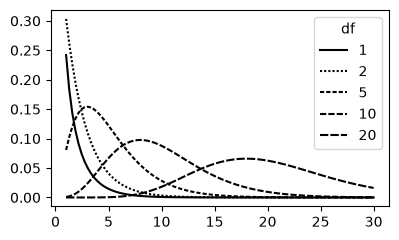

In [26]:
x = [1 + i * (30 - 1) / 99 for i in range(100)]

chi = pd.DataFrame({
    'x': x,
    'chi_1': stats.chi2.pdf(x, df=1),
    'chi_2': stats.chi2.pdf(x, df=2),
    'chi_5': stats.chi2.pdf(x, df=5),
    'chi_10': stats.chi2.pdf(x, df=10),
    'chi_20': stats.chi2.pdf(x, df=20),
})
fig, ax = plt.subplots(figsize=(4, 2.5))
ax.plot(chi.x, chi.chi_1, color='black', linestyle='-', label='1')
ax.plot(chi.x, chi.chi_2, color='black', linestyle=(0, (1, 1)), label='2')
ax.plot(chi.x, chi.chi_5, color='black', linestyle=(0, (2, 1)), label='5')
ax.plot(chi.x, chi.chi_10, color='black', linestyle=(0, (3, 1)), label='10')
ax.plot(chi.x, chi.chi_20, color='black', linestyle=(0, (4, 1)), label='20')
ax.legend(title='df')

plt.tight_layout()
plt.show()

### Fisher's Exact Test

Fisher exact test mengevaluasi tabel kontingensi dengan margin tetap, terutama berguna ketika hitungan kecil membuat aproksimasi chi-square tidak memadai. Contoh tambahan menggunakan tabel conversion 2x2 yang sudah tersedia, dengan alternatif A lebih besar daripada B. Ini berbeda dari tabel tiga headline 2x3. Odds ratio menunjukkan asosiasi, bukan selisih probabilitas dan bukan bukti kausal.

In [27]:
conversion_table = np.array([[200, 23739 - 200], [182, 22588 - 182]])
fisher = stats.fisher_exact(conversion_table, alternative='greater')
print(f'Odds ratio: {fisher.statistic:.4f}')
print(f'Fisher p-value (A > B): {fisher.pvalue:.4f}')

Odds ratio: 1.0460
Fisher p-value (A > B): 0.3499


#### Pola Digit dan Audit Statistik

Pola digit yang tidak wajar dapat menjadi sinyal audit statistik, tetapi bukan bukti final kecurangan. Grafik frekuensi digit harus dibandingkan dengan proses pencatatan yang seharusnya berlaku; pembulatan dan aturan pengukuran juga dapat menimbulkan pola. Jangan menyimpulkan kecurangan hanya dari sebuah histogram.

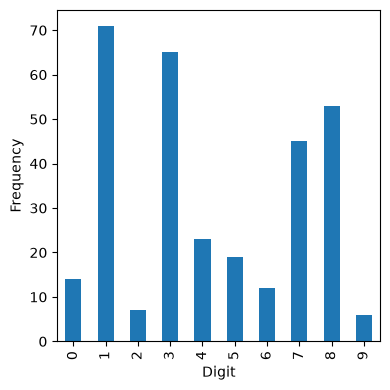

In [28]:
imanishi = pd.read_csv(IMANISHI_CSV)
imanishi.columns = [c.strip() for c in imanishi.columns]
ax = imanishi.plot.bar(x='Digit', y=['Frequency'], legend=False,
                      figsize=(4, 4))
ax.set_xlabel('Digit')
ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

## Power and Sample Size

Type I error berarti menolak $H_0$ yang benar; type II error berarti gagal menolak $H_0$ yang salah. Power adalah $1-\beta$. Efek lebih kecil memerlukan sampel lebih besar untuk power dan alpha sama.

Contoh membandingkan **dua proporsi**, sehingga dipakai `NormalIndPower` dengan effect size Cohen h dari `proportion_effectsize`, bukan `TTestIndPower` untuk mean. Hasil merupakan aproksimasi jumlah pengamatan per kelompok untuk alokasi sama dan uji satu arah. Desain nyata perlu mempertimbangkan biaya, rasio alokasi, dan asumsi.

In [29]:
effect_size = sm.stats.proportion_effectsize(0.0121, 0.011)
analysis = power.NormalIndPower()
result = analysis.solve_power(effect_size=effect_size, 
                              alpha=0.05, power=0.8, alternative='larger')
print('Sample Size: %.3f' % result)

Sample Size: 116601.715


In [30]:
effect_size = sm.stats.proportion_effectsize(0.0165, 0.011)
analysis = power.NormalIndPower()
result = analysis.solve_power(effect_size=effect_size, 
                              alpha=0.05, power=0.8, alternative='larger')
print('Sample Size: %.3f' % result)

Sample Size: 5487.731


## Pemeriksaan hasil dan interpretasi

Sel berikut merangkum hasil utama dan memeriksa konsistensi perhitungan. Assertion mengecek kondisi yang dinyatakan dalam kode; pemeriksaan ini tidak membuktikan seluruh asumsi statistik atau keterwakilan dataset.

In [31]:
print("Mean waktu A dan B:", mean_a, mean_b)
welch = stats.ttest_ind(session_times.loc[session_times.Page == 'Page A', 'Time'],
                        session_times.loc[session_times.Page == 'Page B', 'Time'],
                        equal_var=False, alternative='less')
display(pd.Series({'B_minus_A_seconds': mean_b - mean_a,
                   'Welch_p_A_less_B': welch.pvalue,
                   'conversion_difference_percentage_points': obs_pct_diff}))
groups = [g.Time.to_numpy() for _, g in four_sessions.groupby('Page')]
f_result = stats.f_oneway(*groups)
table = sm.stats.anova_lm(smf.ols('Time ~ C(Page)', data=four_sessions).fit())
assert np.isclose(f_result.statistic, table.loc['C(Page)', 'F'])
assert np.isclose(f_result.pvalue, table.loc['C(Page)', 'PR(>F)'])
print('ANOVA SciPy dan statsmodels cocok:', f_result)


Mean waktu A dan B:

 126.33333333333333 162.0


B_minus_A_seconds                          35.666667
Welch_p_A_less_B                            0.140762
conversion_difference_percentage_points     0.036758
dtype: float64

ANOVA SciPy dan statsmodels cocok: F_onewayResult(statistic=np.float64(2.739825341901467), pvalue=np.float64(0.07758621525801461))


### Interpretasi hasil eksekusi

Mean waktu B lebih tinggi daripada A sekitar **35,67 detik**, tetapi Welch p-value satu arah sekitar **0,141**. Pada alpha 0,05, data ini belum cukup untuk menolak hipotesis nol dengan arah A < B. Selisih yang terlihat sendiri tidak menjamin signifikansi.

ANOVA empat halaman menghasilkan **F = 2,740** dan **p = 0,0776**, juga belum signifikan pada alpha 0,05. Ini tidak membuktikan semua halaman identik. Selisih conversion sekitar **0,0368 poin persentase** perlu dinilai bersama ketidakpastian dan biaya penerapan.

## A/B Testing dan Hypothesis Tests

Kontrol menyediakan pembanding untuk perubahan yang dapat terjadi karena musim, komposisi pengguna, atau faktor lain. Random assignment membantu menyeimbangkan faktor tersebut secara rata-rata. Contoh desain: unit assignment adalah pengguna, treatment adalah tampilan A/B, dan metrik utama ialah conversion per pengguna. Menghitung setiap kunjungan pengguna yang sama sebagai pengamatan independen dapat meremehkan ketidakpastian.

Hipotesis nol harus menyatakan pembanding konkret, misalnya $H_0:p_A=p_B$. Alternatif dua arah $p_A\ne p_B$ menilai kedua arah; alternatif satu arah $p_A>p_B$ hanya arah yang ditetapkan sebelumnya. Menentukan arah setelah melihat data memperbesar peluang false positive. Kontrol, periode eksperimen, metrik, alpha, dan desain penghentian ditetapkan sebelum analisis.

Mengapa tidak langsung A/B/C/D? Banyak pilihan memungkinkan optimasi lebih luas, tetapi membagi traffic sehingga observasi per pilihan berkurang dan menambah masalah multiple testing. ANOVA atau uji omnibus dapat mendeteksi perbedaan keseluruhan; belum mengidentifikasi pasangan tertentu. Pengujian pasangan setelahnya perlu prosedur yang sesuai. Tujuan memilih opsi terbaik untuk bisnis juga berbeda dari menguji semua pasangan secara formal.

## Exhaustive dan Bootstrap Permutation Tests

Permutation acak mengulang pengacakan label tanpa pengembalian untuk membangun distribusi nol. **Exhaustive permutation** menilai seluruh assignment yang mungkin: untuk dua kelompok berukuran nA dan nB, banyaknya pemilihan kelompok A adalah $\binom{n_A+n_B}{n_A}$. Ini cepat menjadi terlalu besar. Untuk assignment equiprobable yang dienumerasi penuh, exact p-value ialah proporsi assignment setidaknya se-ekstrem observasi; koreksi Monte Carlo +1 tidak diperlukan untuk enumerasi penuh.

Istilah **bootstrap permutation** dalam buku mengacu pada resampling dari data gabungan dengan pengembalian. Berbeda dari permutation murni, satu pengamatan dapat muncul berulang dan total kategori dapat berubah. Validitas memerlukan model nol/resampling yang sesuai; bootstrap masing-masing kelompok dengan mempertahankan selisih observasi tidak otomatis merupakan uji H0 kesamaan.

Permutation tidak mensyaratkan normalitas, tetapi masih memerlukan exchangeability menurut desain nol. Data berpasangan, berkelompok, atau berurutan waktu memerlukan pengacakan yang mempertahankan struktur relevan. P-value simulasi mempunyai variasi Monte Carlo: banyak pengulangan memengaruhi ketelitian, bukan besar efek sebenarnya.

## Degrees of Freedom dan Relevansi untuk Pembelajaran Mesin

Mengestimasi mean dari n nilai membuat residual terhadap mean berjumlah nol; hanya n-1 residual bebas. Pada ANOVA dengan k kelompok dan N pengamatan, df antar-kelompok k-1 dan df error N-k. Pada regresi OLS full rank dengan p koefisien termasuk intercept, df residual N-p. Derajat bebas menyesuaikan distribusi acuan dan ketidakpastian, bukan sekadar jumlah baris.

Pada uji independensi tabel r x c, margin membatasi hitungan sehingga df=(r-1)(c-1). Untuk uji goodness-of-fit, df biasanya jumlah kategori dikurangi satu dan dikurangi parameter yang diestimasi dari data. Frekuensi harapan, bukan hanya frekuensi observasi, perlu diperiksa.

Dalam pembelajaran mesin, uji kategori dapat membantu menyaring asosiasi fitur-target, tetapi penyaringan harus dilakukan hanya pada training atau di dalam tiap fold. P-value kecil tidak menunjukkan akurasi prediksi tinggi, efek besar, atau kausalitas. Evaluasi generalisasi, ukuran efek, dan biaya keputusan tetap diperlukan. Alpha membatasi risiko type I dalam prosedur yang valid; gagal menolak H0 belum membuktikan kesetaraan. Multiple testing dan penghentian adaptif dapat merusak interpretasi p-value biasa.

## Multi-Arm Bandit Algorithm

Satu **arm** adalah satu alternatif, misalnya tiga headline. **Reward** adalah hasil yang dioptimalkan, misalnya 1 untuk klik dan 0 untuk tidak klik. **Exploration** mencoba alternatif untuk memperoleh informasi; **exploitation** menggunakan alternatif yang saat ini tampak paling menguntungkan. Terlalu cepat memilih pemenang dapat mengunci pilihan yang salah karena noise; pembagian traffic selalu sama dapat membuang peluang reward pada opsi kurang baik.

### Epsilon-Greedy

Pada setiap keputusan, dengan probabilitas epsilon pilih arm secara acak; selain itu pilih arm dengan estimasi reward rata-rata tertinggi. epsilon=1 berarti seluruh keputusan eksplorasi uniform; epsilon=0 berarti greedy sesudah inisialisasi. Nilai epsilon kecil masih memberi peluang mencoba arm lain, tetapi tidak menjamin pemenang ditemukan dalam horizon singkat.

### Thompson Sampling

Untuk reward Bernoulli, gunakan prior Beta(a,b) pada peluang sukses setiap arm. Setelah reward 1, tambah a; setelah reward 0, tambah b. Pada keputusan berikutnya, ambil satu nilai dari posterior setiap arm dan pilih nilai terbesar. Ketidakpastian posterior memungkinkan arm yang belum banyak dicoba tetap terpilih. Prior Beta(1,1) pada contoh tambahan berarti uniform sebelum observasi, bukan peluang reward sebenarnya sudah diketahui.

### Tujuan dan Batasan

Bandit mengalokasikan observasi secara adaptif untuk meningkatkan total reward selama proses berjalan; A/B klasik biasanya memberi alokasi tetap untuk inferensi perbedaan. **Expected cumulative regret** membandingkan expected reward policy dengan selalu memilih arm terbaik pada model simulasi. Dalam aplikasi nyata, arm terbaik belum diketahui, sehingga regret sebenarnya tidak langsung teramati. Reward yang tertunda, tren waktu, atau perubahan preferensi dapat membuat model stationary tidak cocok. Data adaptif tidak boleh langsung dianalisis dengan p-value A/B biasa seolah alokasi tetap.

Simulasi di bawah adalah ilustrasi tambahan memakai probabilitas sintetis, bukan dataset pengguna. Dua policy ditunjukkan pada satu seed untuk belajar mekanisme; bukan eksperimen yang membuktikan satu algoritma selalu unggul.

In [32]:
def simulate_bandit(policy, horizon=3000, epsilon=0.1, seed=42):
    rng = np.random.default_rng(seed)
    true_probabilities = np.array([0.05, 0.08, 0.12])
    pulls = np.zeros(3, dtype=int)
    successes = np.zeros(3, dtype=int)
    expected_regret = 0.0
    for step in range(horizon):
        if step < 3:  # beri setiap arm satu observasi awal
            arm = step
        elif policy == 'epsilon-greedy':
            if rng.random() < epsilon:
                arm = int(rng.integers(3))
            else:
                estimates = successes / pulls
                best = np.flatnonzero(estimates == estimates.max())
                arm = int(rng.choice(best))  # tie tidak selalu memilih arm pertama
        elif policy == 'thompson':
            arm = int(np.argmax(rng.beta(1 + successes, 1 + pulls - successes)))
        else:
            raise ValueError(policy)
        reward = int(rng.random() < true_probabilities[arm])
        pulls[arm] += 1
        successes[arm] += reward
        expected_regret += true_probabilities.max() - true_probabilities[arm]
    assert pulls.sum() == horizon and np.all(successes <= pulls)
    return pd.DataFrame({'policy': policy, 'arm': ['A', 'B', 'C'],
                         'pulls': pulls, 'successes': successes,
                         'estimated_reward_rate': successes / pulls}), expected_regret

bandit_results = []
for bandit_policy in ['epsilon-greedy', 'thompson']:
    bandit_table, bandit_regret = simulate_bandit(bandit_policy)
    bandit_results.append(bandit_table)
    print(bandit_policy, 'expected cumulative regret:', round(bandit_regret, 2))
display(pd.concat(bandit_results, ignore_index=True))
print('Interpretasi: alokasi berubah dari estimasi reward, bukan selalu 1/3 untuk tiap arm.')

epsilon-greedy

expected cumulative regret: 13.12


thompson expected cumulative regret: 16.96


,policy,arm,pulls,successes,estimated_reward_rate
0,epsilon-greedy,A,96,6,0.062500
1,epsilon-greedy,B,160,13,0.081250
2,epsilon-greedy,C,2744,329,0.119898
3,thompson,A,68,2,0.029412
4,thompson,B,305,28,0.091803
5,thompson,C,2627,315,0.119909


Interpretasi: alokasi berubah dari estimasi reward, bukan selalu 1/3 untuk tiap arm.


## Ringkasan bab

Eksperimen yang baik menetapkan metrik, hipotesis, dan arah uji sebelum melihat hasil. Pada contoh waktu halaman web, rata-rata B sekitar **162 detik** dan A **126,33 detik**, dengan selisih B-A **35,67 detik**. Welch t-test satu arah menghasilkan **p sekitar 0,141**. Pada alpha 0,05, hasil ini belum cukup untuk menolak hipotesis nol; hal itu tidak membuktikan kedua mean identik.

P-value adalah peluang memperoleh statistik setidaknya se-ekstrem hasil observasi jika hipotesis nol dan asumsi uji berlaku. Karena itu, p=0,2 tidak berarti hipotesis nol benar dengan peluang 80%. Besar efek dan ketidakpastian tetap perlu dilaporkan bersama p-value.

Pada contoh ANOVA, **F sekitar 2,740** dan **p sekitar 0,0776** belum memberi bukti yang cukup pada alpha 0,05 untuk menolak kesamaan mean seluruh kelompok. ANOVA merupakan uji gabungan, sehingga tidak langsung menentukan pasangan kelompok mana yang berbeda. Jika diperlukan perbandingan pasangan, prosedur lanjutan harus memperhitungkan multiple testing. Efek conversion yang kecil membutuhkan sampel lebih besar karena selisih tersebut lebih sulit dibedakan dari variasi acak pada power dan alpha yang sama.

Multi-arm bandit menyeimbangkan exploration dan exploitation untuk meningkatkan reward selama proses berjalan. Epsilon nol membuat policy greedy setelah inisialisasi, sehingga estimasi awal yang kebetulan tinggi dapat mengunci pilihan yang kurang baik. Thompson sampling memakai ketidakpastian posterior untuk menentukan pilihan berikutnya. Hasil satu seed merupakan ilustrasi mekanisme, bukan bukti satu policy selalu unggul. Karena alokasi bandit berubah mengikuti hasil sebelumnya, p-value A/B biasa dengan asumsi alokasi tetap tidak dapat langsung diterapkan tanpa mempertimbangkan desain adaptif.